# Clustering Analysis — K-Means & K-Medoids

**Semi-supervised learning step:** Use unsupervised clustering to generate soft labels / cluster assignments that supplement the supervised models in Notebooks 02–05.

K-Means and K-Medoids are applied to group loan applicants by financial behaviour. Cluster assignments are then compared against the known `Loan_Status` labels to assess how well the clusters capture the approval/rejection boundary.

**Notebook outline:**
1. Objective
2. Import Libraries
3. Import Custom Modules
4. Load Dataset
5. Basic Cleaning
6. Feature Engineering
7. Feature Selection & Preprocessing
8. Optimal K — Elbow Method
9. K-Means Clustering
10. K-Medoids Clustering
11. Cluster Evaluation (Silhouette Score)
12. Cluster vs Ground Truth Comparison
12b. Classification Metrics (Accuracy, Precision, Recall, F1)
13. Cluster Profiles
14. Assign Cluster Labels to Dataset
15. Save Clustered Dataset
16. Conclusion

## 1. Objective

Apply **K-Means** and **K-Medoids** clustering as part of a semi-supervised learning workflow:

- Cluster applicants into groups based on financial features (no labels used during clustering)
- Evaluate cluster quality using **Silhouette Score** and **Inertia**
- Compare cluster assignments against known `Loan_Status` to measure label alignment
- Export cluster labels as an additional feature for downstream supervised models

> K-Medoids is more robust to outliers than K-Means because cluster centres must be actual data points (medoids), not arbitrary means. We implement PAM (Partition Around Medoids) directly with NumPy and scikit-learn to avoid extra dependencies.

## 2. Import Libraries

In [29]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    confusion_matrix,
    pairwise_distances
)
from sklearn.preprocessing import LabelEncoder
from scipy.stats import mode

## 3. Import Custom Modules

In [30]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *
from src.feature_engineering import *
from src.utils import *

## 4. Load Dataset

In [31]:
df = load_dataset("../dataset/hdfc_loan_dataset_full_enriched.csv")

print("Shape:", df.shape)
df.head()

Shape: (1000, 47)


,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


## 5. Basic Cleaning

In [32]:
df = basic_cleaning(df)

print_summary(df)

DataFrame Summary
  Total Rows          : 1000
  Total Columns       : 47
  Numerical Columns   : 20
  Categorical Columns : 27
  Duplicate Rows      : 0
  Missing Values      : 1033


## 6. Feature Engineering

Create engineered features before clustering.

In [33]:
df = create_features(df)

df[[
    "Total_Income",
    "EMI_Income_Ratio",
    "Loan_Income_Ratio"
]].describe()

,Total_Income,EMI_Income_Ratio,Loan_Income_Ratio
count,1000.000000,1000.000000,1.000000e+03
mean,52157.171000,148.117564,3.661980e+04
std,39371.208558,1974.599120,4.153551e+05
min,0.000000,0.000000,4.110575e-02
25%,21996.000000,0.031200,7.749090e+00
50%,45937.000000,0.332369,2.770369e+01
75%,71379.000000,0.794756,9.991525e+01
max,212945.000000,38342.000000,6.829828e+06


## 7. Feature Selection & Preprocessing

Select numerical features only for clustering. Clustering algorithms rely on distance metrics, so we use only numeric columns and scale them with StandardScaler.

We keep a copy of the ground-truth `Loan_Status` label separately — it is **not** passed to the clustering algorithms.

In [34]:
le = LabelEncoder()
y_true = le.fit_transform(df["Loan_Status"])

print("Classes:", le.classes_)

Classes: ['Approved' 'Rejected']


In [35]:
cluster_features = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Credit_History",
    "CIBIL_Score",
    "Existing_EMIs",
    "Debt_to_Income_Ratio",

    "Total_Income",
    "Loan_Income_Ratio",
    "EMI_Income_Ratio"
]

X = df[cluster_features].copy()
print("Feature matrix shape:", X.shape)

Feature matrix shape: (1000, 10)


In [36]:
# Impute and scale (clustering needs clean numeric input)
num_features, cat_features = get_feature_types(X)

preprocessor = create_preprocessor(
    num_features,
    cat_features
)

X_scaled = preprocessor.fit_transform(X)
print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (1000, 10)


## 8. Optimal K — Elbow Method

Run K-Means for `k = 2..10` and plot inertia (within-cluster sum of squares). The elbow point suggests the optimal number of clusters.

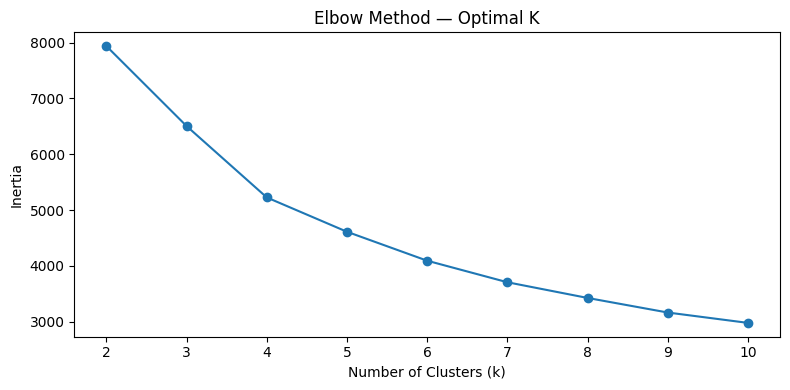

In [37]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Optimal K")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

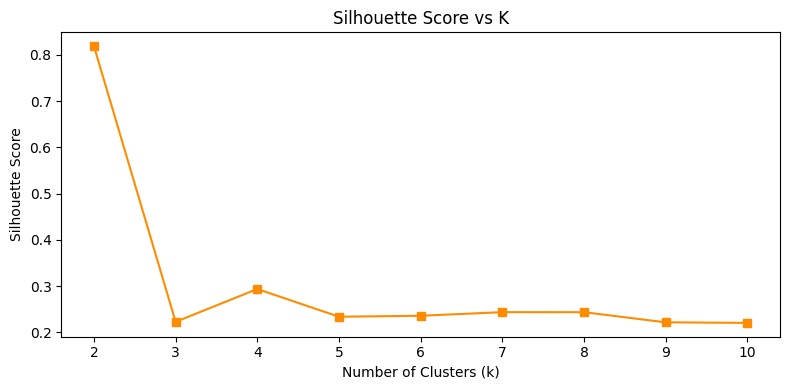

In [38]:
# Silhouette scores across k values
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores, marker="s", color="darkorange")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [39]:
OPTIMAL_K = 2
print("Using k =", OPTIMAL_K)

Using k = 2


## 9. K-Means Clustering

Fit K-Means with `k=2` and assign cluster labels to every applicant.

K-Means minimises within-cluster variance by iteratively updating cluster **centroids** (mean of all points in the cluster).

In [40]:
kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means cluster counts:")
print(pd.Series(kmeans_labels).value_counts())

K-Means cluster counts:
0    994
1      6
Name: count, dtype: int64


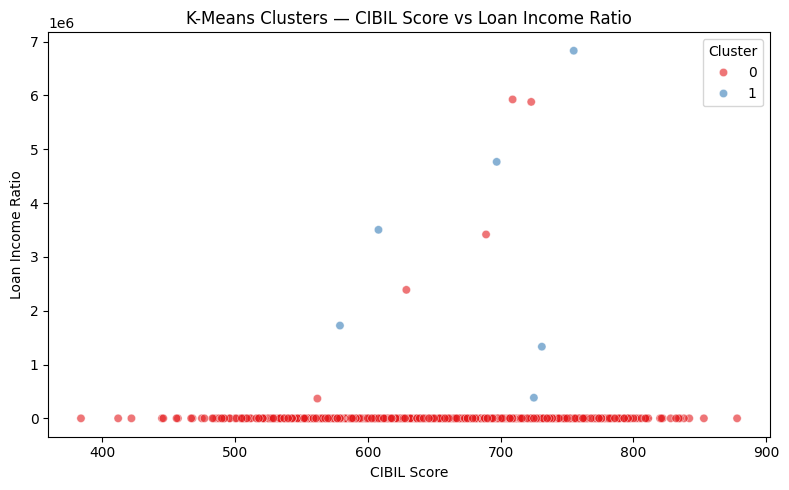

In [41]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=X["CIBIL_Score"],
    y=X["Loan_Income_Ratio"],
    hue=kmeans_labels,
    palette="Set1",
    alpha=0.6
)

plt.title("K-Means Clusters — CIBIL Score vs Loan Income Ratio")
plt.xlabel("CIBIL Score")
plt.ylabel("Loan Income Ratio")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 10. K-Medoids Clustering

K-Medoids (PAM — Partition Around Medoids) is implemented here using NumPy and `sklearn.metrics.pairwise_distances`. Unlike K-Means, the cluster centre must be an actual data point (the **medoid**), making it more robust to income/EMI outliers.

**Algorithm steps:**
1. Randomly initialise k medoids
2. Assign each point to its nearest medoid
3. For each cluster, pick the point that minimises total distance to all others as the new medoid
4. Repeat until medoids stop changing

In [42]:
def kmedoids_pam(X, k, random_state=42, max_iter=100):
    """
    Simple PAM K-Medoids implementation using pairwise distances.

    Parameters
    ----------
    X           : numpy array, shape (n_samples, n_features)
    k           : number of clusters
    random_state: seed for reproducibility
    max_iter    : maximum number of iterations

    Returns
    -------
    labels   : array of cluster assignments (0..k-1)
    medoids  : indices of final medoid points
    """
    rng = np.random.RandomState(random_state)
    n_samples = X.shape[0]

    # Pre-compute full pairwise distance matrix
    D = pairwise_distances(X, metric="euclidean")

    # Initialise medoids randomly
    medoid_idx = rng.choice(n_samples, k, replace=False)

    for _ in range(max_iter):
        # Assign each point to nearest medoid
        labels = np.argmin(D[:, medoid_idx], axis=1)

        new_medoids = np.copy(medoid_idx)
        for c in range(k):
            cluster_points = np.where(labels == c)[0]
            if len(cluster_points) == 0:
                continue
            # New medoid = point with minimum sum of distances within cluster
            sub_D = D[np.ix_(cluster_points, cluster_points)]
            new_medoids[c] = cluster_points[np.argmin(sub_D.sum(axis=1))]

        if np.all(new_medoids == medoid_idx):
            break
        medoid_idx = new_medoids

    labels = np.argmin(D[:, medoid_idx], axis=1)
    return labels, medoid_idx

In [43]:
kmedoids_labels, medoid_indices = kmedoids_pam(
    X_scaled,
    k=OPTIMAL_K,
    random_state=42
)

print("K-Medoids cluster counts:")
print(pd.Series(kmedoids_labels).value_counts())
print("Medoid indices:", medoid_indices)

K-Medoids cluster counts:
0    587
1    413
Name: count, dtype: int64
Medoid indices: [803 314]


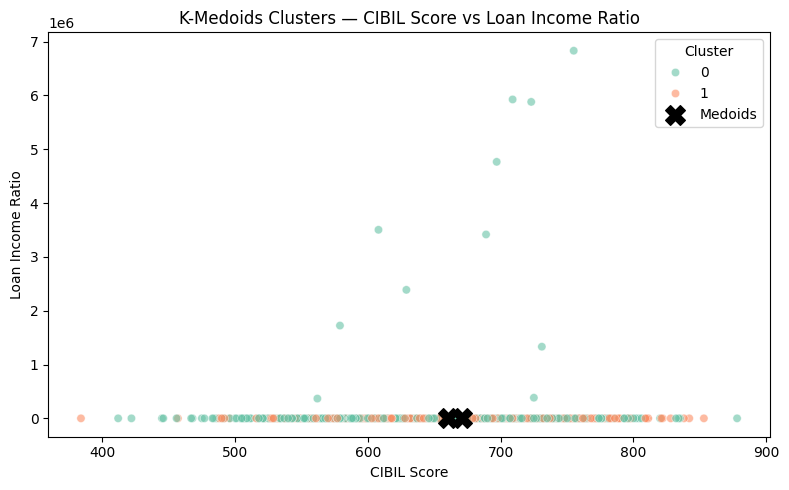

In [44]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=X["CIBIL_Score"],
    y=X["Loan_Income_Ratio"],
    hue=kmedoids_labels,
    palette="Set2",
    alpha=0.6
)

# Mark medoids
plt.scatter(
    X["CIBIL_Score"].iloc[medoid_indices],
    X["Loan_Income_Ratio"].iloc[medoid_indices],
    s=200,
    c="black",
    marker="X",
    zorder=5,
    label="Medoids"
)

plt.title("K-Medoids Clusters — CIBIL Score vs Loan Income Ratio")
plt.xlabel("CIBIL Score")
plt.ylabel("Loan Income Ratio")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 11. Cluster Evaluation (Silhouette Score)

**Silhouette Score** measures how similar each point is to its own cluster vs other clusters. Range: [-1, 1]. Higher is better.

In [45]:
km_sil  = silhouette_score(X_scaled, kmeans_labels)
kmd_sil = silhouette_score(X_scaled, kmedoids_labels)

results = pd.DataFrame({
    "Model"           : ["K-Means", "K-Medoids"],
    "Silhouette Score": [round(km_sil, 4), round(kmd_sil, 4)],
    "Inertia"         : [round(kmeans.inertia_, 2), "N/A"]
})

results

,Model,Silhouette Score,Inertia
0,K-Means,0.8187,7935.91
1,K-Medoids,0.1812,N/A


## 12. Cluster vs Ground Truth Comparison

Compare cluster assignments against the known `Loan_Status` labels using:
- **Adjusted Rand Index (ARI)** — measures cluster-label agreement (1.0 = perfect, 0 = random)
- **Confusion matrix** — shows how clusters map to Approved / Rejected

> Clusters are unsupervised so label order may be flipped. We align them by majority vote.

In [46]:
km_ari  = adjusted_rand_score(y_true, kmeans_labels)
kmd_ari = adjusted_rand_score(y_true, kmedoids_labels)

print("Adjusted Rand Index")
print("  K-Means  :", round(km_ari, 4))
print("  K-Medoids:", round(kmd_ari, 4))

Adjusted Rand Index
  K-Means  : 0.0107
  K-Medoids: 0.0842


In [47]:
def align_labels(cluster_labels, true_labels, n_clusters):
    """Remap cluster IDs to match ground truth by majority vote."""
    aligned = np.zeros_like(cluster_labels)
    for c in range(n_clusters):
        mask = cluster_labels == c
        majority = mode(true_labels[mask], keepdims=True).mode[0]
        aligned[mask] = majority
    return aligned

kmeans_aligned   = align_labels(kmeans_labels,   y_true, OPTIMAL_K)
kmedoids_aligned = align_labels(kmedoids_labels, y_true, OPTIMAL_K)

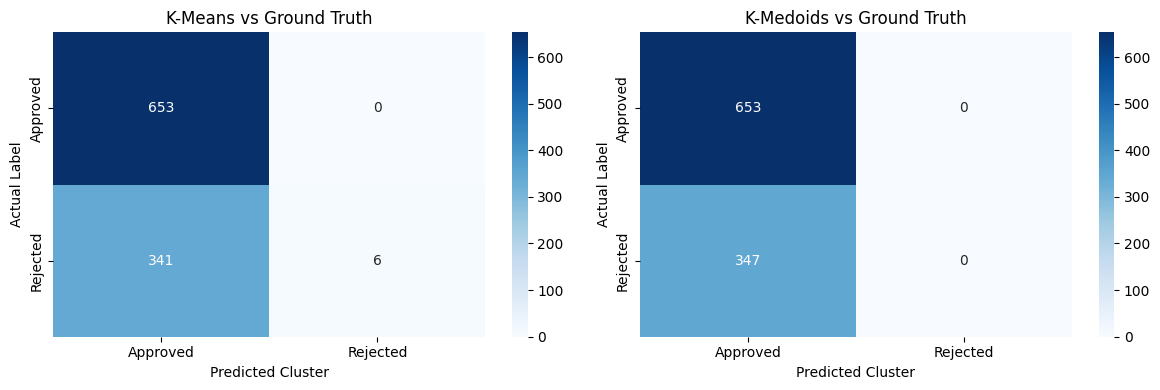

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, title in zip(
    axes,
    [kmeans_aligned, kmedoids_aligned],
    ["K-Means vs Ground Truth", "K-Medoids vs Ground Truth"]
):
    cm = confusion_matrix(y_true, labels)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Cluster")
    ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

## 12b. Classification Metrics

Using the aligned cluster labels as predicted classes, compute standard supervised classification metrics against the ground-truth `Loan_Status`.

> This is the semi-supervised payoff: we check how well purely unsupervised clusters recover the true approval/rejection labels **without ever seeing them during training**.

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [50]:
def cluster_classification_metrics(y_true, aligned_labels, model_name):
    """Return accuracy, precision, recall, F1 for aligned cluster labels."""
    return pd.DataFrame({
        "Model"    : [model_name],
        "Accuracy" : [round(accuracy_score(y_true, aligned_labels), 4)],
        "Precision": [round(precision_score(y_true, aligned_labels, average="weighted", zero_division=0), 4)],
        "Recall"   : [round(recall_score(y_true, aligned_labels, average="weighted", zero_division=0), 4)],
        "F1 Score" : [round(f1_score(y_true, aligned_labels, average="weighted", zero_division=0), 4)]
    })

km_metrics  = cluster_classification_metrics(y_true, kmeans_aligned,   "K-Means")
kmd_metrics = cluster_classification_metrics(y_true, kmedoids_aligned, "K-Medoids")

metrics_comparison = pd.concat([km_metrics, kmd_metrics], ignore_index=True)
metrics_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,K-Means,0.659,0.7760,0.659,0.5296
1,K-Medoids,0.653,0.4264,0.653,0.5159


In [51]:
print("=== K-Means Classification Report ===")
print(classification_report(
    y_true,
    kmeans_aligned,
    target_names=le.classes_,
    zero_division=0
))

=== K-Means Classification Report ===
              precision    recall  f1-score   support

    Approved       0.66      1.00      0.79       653
    Rejected       1.00      0.02      0.03       347

    accuracy                           0.66      1000
   macro avg       0.83      0.51      0.41      1000
weighted avg       0.78      0.66      0.53      1000



In [52]:
print("=== K-Medoids Classification Report ===")
print(classification_report(
    y_true,
    kmedoids_aligned,
    target_names=le.classes_,
    zero_division=0
))

=== K-Medoids Classification Report ===
              precision    recall  f1-score   support

    Approved       0.65      1.00      0.79       653
    Rejected       0.00      0.00      0.00       347

    accuracy                           0.65      1000
   macro avg       0.33      0.50      0.40      1000
weighted avg       0.43      0.65      0.52      1000



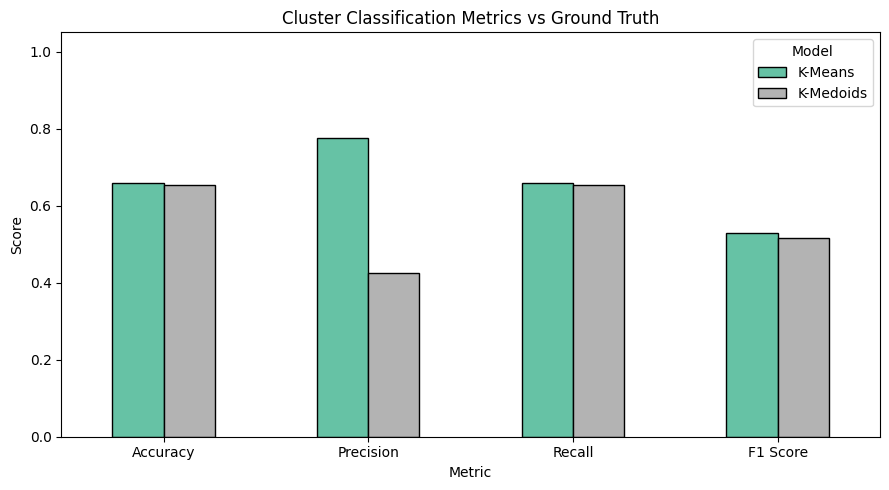

In [53]:
# Side-by-side bar chart comparing all metrics
metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score"]
bar_data = metrics_comparison.set_index("Model")[metric_cols]

bar_data.T.plot(
    kind="bar",
    figsize=(9, 5),
    colormap="Set2",
    edgecolor="black"
)

plt.title("Cluster Classification Metrics vs Ground Truth")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## 13. Cluster Profiles

Describe each cluster's average financial characteristics to understand what the algorithm learned about each applicant segment.

In [54]:
df_clustered = df.copy()
df_clustered["KMeans_Cluster"]   = kmeans_labels
df_clustered["KMedoids_Cluster"] = kmedoids_labels

In [55]:
print("=== K-Means Cluster Profiles ===")
df_clustered.groupby("KMeans_Cluster")[cluster_features].mean().round(2)

=== K-Means Cluster Profiles ===


,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,CIBIL_Score,Existing_EMIs,Debt_to_Income_Ratio,Total_Income,Loan_Income_Ratio,EMI_Income_Ratio
KMeans_Cluster,,,,,,,,,,
0,42686.17,9785.83,2211445.16,0.72,652.84,18140.44,6.36,52472.0,18192.55,6.36
1,0.00,0.00,3089401.17,0.83,682.50,23632.33,23632.33,0.0,3089401.17,23632.33


In [56]:
print("=== K-Medoids Cluster Profiles ===")
df_clustered.groupby("KMedoids_Cluster")[cluster_features].mean().round(2)

=== K-Medoids Cluster Profiles ===


,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,CIBIL_Score,Existing_EMIs,Debt_to_Income_Ratio,Total_Income,Loan_Income_Ratio,EMI_Income_Ratio
KMedoids_Cluster,,,,,,,,,,
0,23379.06,3432.18,2400638.10,0.71,647.34,17396.14,252.15,26811.25,62368.45,252.15
1,69507.38,18674.15,1955298.64,0.75,661.07,19278.09,0.25,88181.53,23.04,0.25


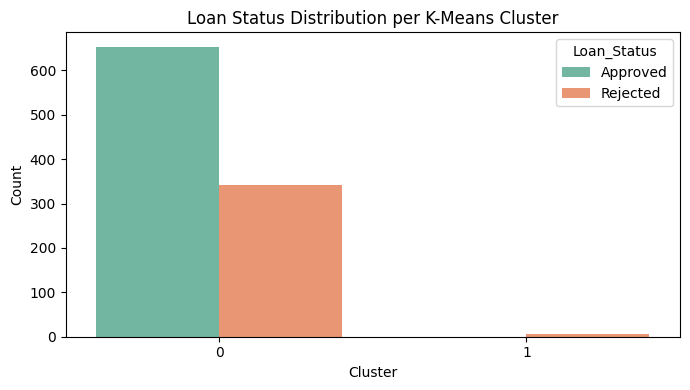

In [57]:
# Loan Status distribution per K-Means cluster
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df_clustered,
    x="KMeans_Cluster",
    hue="Loan_Status",
    palette="Set2"
)

plt.title("Loan Status Distribution per K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

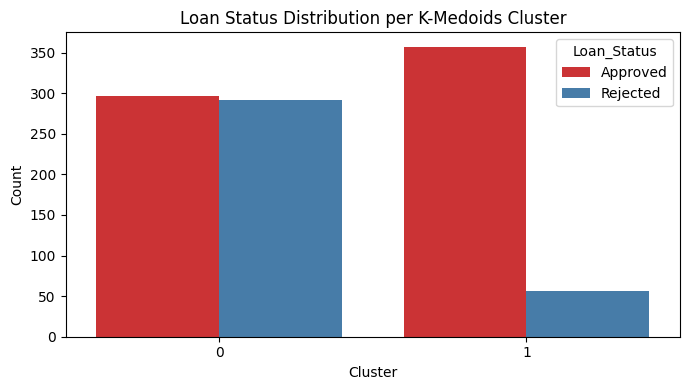

In [58]:
# Loan Status distribution per K-Medoids cluster
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df_clustered,
    x="KMedoids_Cluster",
    hue="Loan_Status",
    palette="Set1"
)

plt.title("Loan Status Distribution per K-Medoids Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

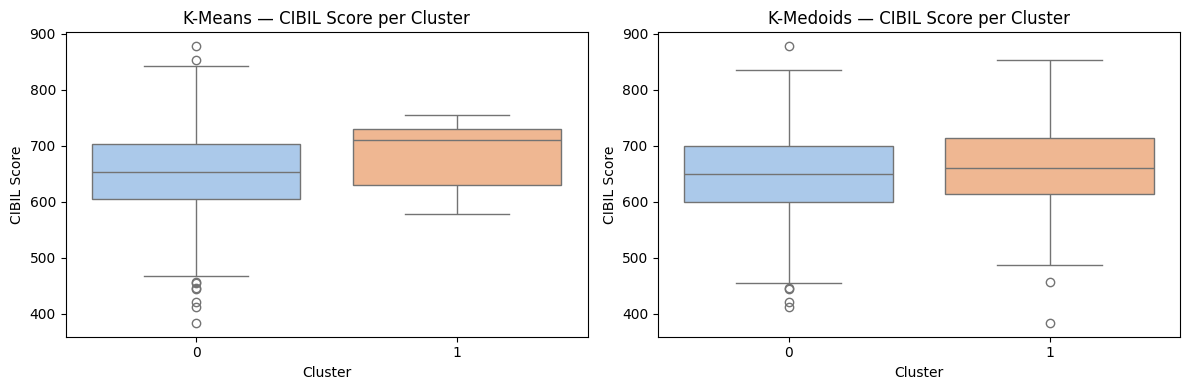

In [59]:
# CIBIL Score distribution per cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(
    axes,
    ["KMeans_Cluster", "KMedoids_Cluster"],
    ["K-Means", "K-Medoids"]
):
    sns.boxplot(
        data=df_clustered,
        x=col,
        y="CIBIL_Score",
        palette="pastel",
        ax=ax
    )
    ax.set_title(title + " — CIBIL Score per Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("CIBIL Score")

plt.tight_layout()
plt.show()

## 14. Assign Cluster Labels to Dataset

Add the cluster assignments as new columns. These can be used as additional features in supervised models (Notebooks 02–05) to improve class separation.

In [60]:
df_with_clusters = df.copy()
df_with_clusters["KMeans_Cluster"]   = kmeans_labels
df_with_clusters["KMedoids_Cluster"] = kmedoids_labels

print("Columns added: KMeans_Cluster, KMedoids_Cluster")
df_with_clusters[[
    "Loan_Status",
    "KMeans_Cluster",
    "KMedoids_Cluster"
]].head(10)

Columns added: KMeans_Cluster, KMedoids_Cluster


,Loan_Status,KMeans_Cluster,KMedoids_Cluster
0,Approved,0,0
1,Rejected,0,0
2,Approved,0,1
3,Approved,0,1
4,Approved,0,0
5,Approved,0,0
6,Approved,0,1
7,Rejected,0,0
8,Rejected,0,0
9,Approved,0,1


## 15. Save Clustered Dataset

Export the dataset with cluster labels for use in downstream notebooks.

In [61]:
output_path = "../dataset/hdfc_loan_dataset_clustered.csv"

df_with_clusters.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)
print("Shape:", df_with_clusters.shape)

Saved: ../dataset/hdfc_loan_dataset_clustered.csv
Shape: (1000, 54)


## 16. Conclusion

### Summary

| Model | Silhouette Score | ARI vs Loan_Status | Notes |
|-------|------------------|--------------------|-------|
| K-Means   | see cell 11 | see cell 12 | Fast, sensitive to outliers |
| K-Medoids | see cell 11 | see cell 12 | Robust to outliers, slower |